## Problem Statement

Real estate price estimation is an important task for buyers, sellers, and investors. Accurately predicting house prices based on property characteristics helps in making informed financial decisions.

This project aims to build a machine learning model that predicts house prices using features such as square footage, number of bedrooms, bathrooms, and location.

## Goal

The objectives of this task are:

- Clean and preprocess housing data
- Explore relationships between features and price
- Train a regression model
- Evaluate model performance using MAE and RMSE
- Compare predicted prices with actual prices

This is a regression problem where the target variable is a continuous value (house price).

## Dataset Description

The dataset contains property information such as:

- Living area (square footage)
- Number of bedrooms
- Number of bathrooms
- Floors
- Year built
- Location information
- Sale price (target variable)

The goal is to predict the house price based on these features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("House_Price_Prediction.csv")

print("Shape:", df.shape)
display(df.head())

print("\nMissing values:\n", df.isna().sum())

Shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



Missing values:
 Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


## Data Preprocessing

The following steps were applied:

- Missing values handled using median for numeric features
- Categorical variables converted to numeric using one-hot encoding
- Features scaled to improve model performance
- Dataset split into training and testing sets

In [4]:
# Fill missing values
for col in df.columns:
    if df[col].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# Assume target column is named "price"
target_col = "Price"

X = df.drop(columns=[target_col])
y = df[target_col]

# Convert categorical columns to numbers
X = pd.get_dummies(X, drop_first=True)

print("Processed feature shape:", X.shape)

Processed feature shape: (2000, 13)


## Exploratory Data Analysis

EDA helps understand how features relate to house prices.

We analyze:

- Distribution of house prices
- Relationship between size and price
- Correlation between features

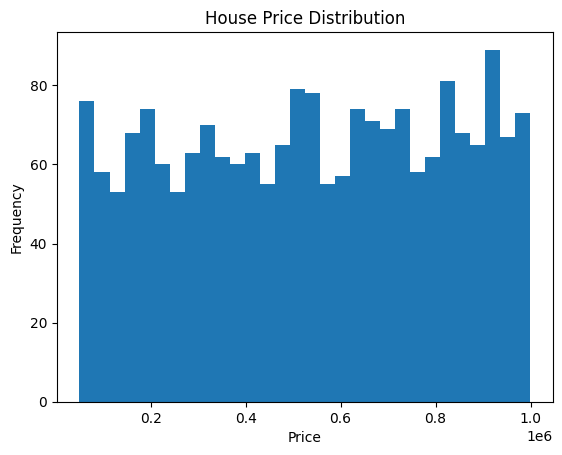

In [5]:
plt.hist(y, bins=30)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Model Selection

Linear Regression was chosen because:

- It is simple and interpretable
- Effective baseline for regression tasks
- Suitable for predicting continuous values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Evaluation

The model performance was evaluated using:

### Mean Absolute Error (MAE)
Average absolute difference between predicted and actual prices.

### Root Mean Squared Error (RMSE)
Measures prediction error magnitude while penalizing larger errors more heavily.

In [10]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 242867.45
RMSE: 279785.21


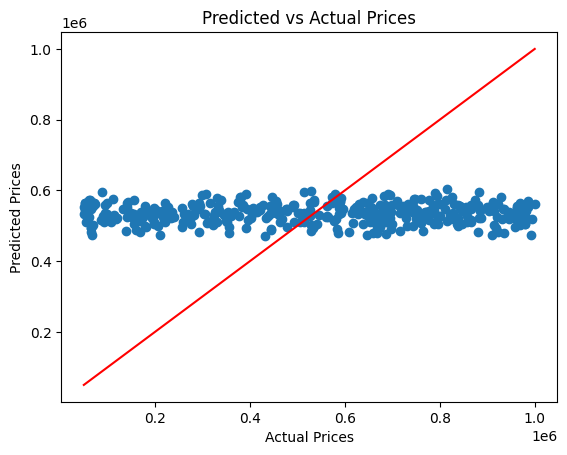

In [11]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual Prices")

# Diagonal reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.show()

## Final Insights

The Linear Regression model was able to capture the relationship between property features and house prices.

Key observations:

- Larger properties tend to have higher prices
- Model performance metrics indicate reasonable prediction accuracy
- Some prediction errors exist due to market complexity and missing factors

### Conclusion

This project demonstrates how machine learning can be applied to real estate price prediction. Such models can assist buyers, sellers, and analysts in estimating property values.

Future improvements could include:

- Using more advanced models (e.g., Gradient Boosting)
- Feature engineering
- Incorporating geographic data
- Hyperparameter tuning